# Xarray-Spatial Multispectral: NDSI, NDBI, BAI, MSAVI2, and OSAVI

Five spectral indices covering snow mapping, urban land use, burn scar detection, and soil-aware vegetation analysis. Each index takes two input bands and runs on all four xrspatial backends (NumPy, Dask, CuPy, Dask+CuPy). This notebook demonstrates them on synthetic reflectance data so you can see the formulas in action without needing real imagery.

### What you'll build

1. Generate synthetic multispectral bands (green, red, NIR, SWIR) with snow, urban, burned, and vegetated zones
2. Compute NDSI to separate snow from clouds and bare ground
3. Compute NDBI to pick out built-up urban areas
4. Compute BAI to detect burn scars via spectral distance to charcoal
5. Compute MSAVI2 for soil-aware vegetation mapping without parameter tuning
6. Compute OSAVI as a fixed-parameter alternative to SAVI
7. Compare all five indices in a single panel

![Spectral indices comparison](images/spectral_indices_preview.png)

[Spectral bands](#Spectral-bands) · [NDSI](#NDSI) · [NDBI](#NDBI) · [BAI](#BAI) · [MSAVI2](#MSAVI2) · [OSAVI](#OSAVI) · [All five together](#All-five-together)

Standard imports plus the five new spectral index functions.

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

from xrspatial.multispectral import ndsi, ndbi, bai, msavi2, osavi

## Spectral bands

We build a 300x400 synthetic scene with five land-cover types and approximate surface reflectance values for green, red, NIR, and SWIR1 bands:

- **Snow** (upper-left arc): high green reflectance, very low SWIR
- **Urban** (central strip): moderate-to-high SWIR, low NIR
- **Burned** (lower-right patch): red and NIR near the charcoal point (0.1, 0.06)
- **Vegetation** (scattered): high NIR, low red
- **Bare soil** (background): moderate reflectance across all bands

In [2]:
np.random.seed(35)
rows, cols = 300, 400
y = np.arange(rows, dtype=float)
x = np.arange(cols, dtype=float)
yy, xx = np.meshgrid(y, x, indexing='ij')

# Land-cover masks
snow_mask = np.sqrt((yy - 30)**2 + (xx - 60)**2) < 55
urban_mask = (~snow_mask) & (np.abs(yy - 150) < 20) & (xx > 80) & (xx < 320)
burn_mask = (~snow_mask) & (~urban_mask) & (np.sqrt((yy - 240)**2 + (xx - 310)**2) < 50)

# Vegetation patches via a sine pattern
veg_field = np.sin(2 * np.pi * yy / 120) * np.cos(2 * np.pi * xx / 160)
veg_mask = (~snow_mask) & (~urban_mask) & (~burn_mask) & (veg_field > 0.3)
soil_mask = ~(snow_mask | urban_mask | burn_mask | veg_mask)

def make_band(snow_v, urban_v, burn_v, veg_v, soil_v, noise=0.008):
    """Assign reflectance by land cover, add noise, clip to valid range."""
    band = np.select(
        [snow_mask, urban_mask, burn_mask, veg_mask, soil_mask],
        [snow_v, urban_v, burn_v, veg_v, soil_v],
    )
    band = band + np.random.normal(0, noise, band.shape)
    return xr.DataArray(
        np.clip(band, 0.001, 1.0).astype(np.float32),
        dims=['y', 'x'], coords={'y': y, 'x': x},
    )

#                     snow   urban  burned  veg    soil
green = make_band(    0.85,  0.12,  0.06,   0.08,  0.18)
red   = make_band(    0.80,  0.14,  0.10,   0.05,  0.22)
nir   = make_band(    0.75,  0.12,  0.06,   0.45,  0.28)
swir1 = make_band(    0.05,  0.30,  0.20,   0.18,  0.32)

Four bands on the same 300x400 grid. Snow is bright in green/red/NIR but dark in SWIR. Vegetation pops in NIR. The burned patch has reflectance close to charcoal (red~0.1, NIR~0.06).

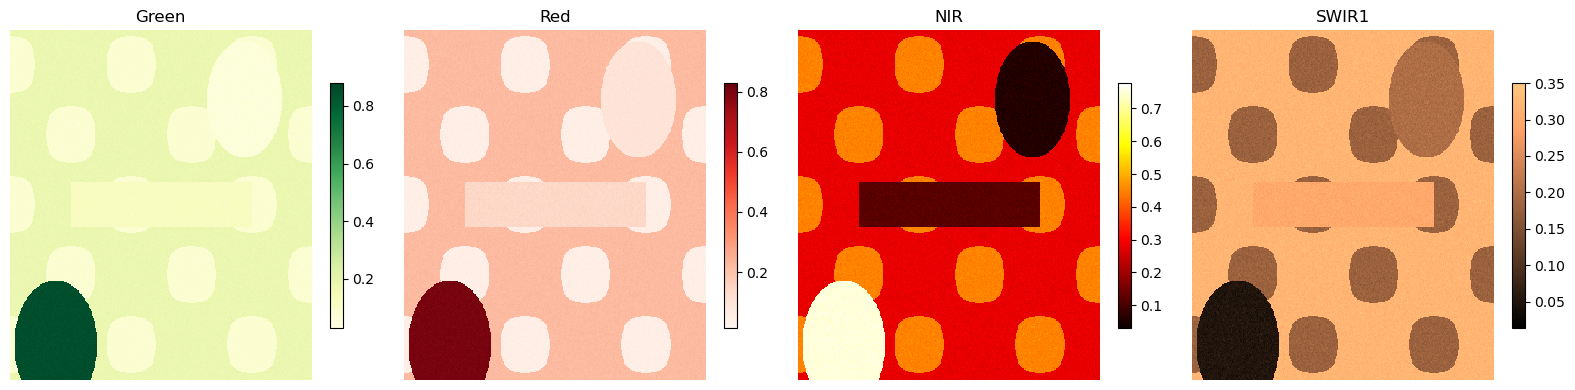

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, band, name, cmap in zip(
    axes,
    [green, red, nir, swir1],
    ['Green', 'Red', 'NIR', 'SWIR1'],
    ['YlGn', 'Reds', 'hot', 'copper'],
):
    band.plot.imshow(ax=ax, cmap=cmap, add_colorbar=True,
                     cbar_kwargs={'shrink': 0.7})
    ax.set_title(name, fontsize=12)
    ax.set_axis_off()
plt.tight_layout()

## NDSI

The [Normalized Difference Snow Index](https://nsidc.org/data/mod10a1) (Hall et al. 1995) computes `(Green - SWIR1) / (Green + SWIR1)`. Snow reflects green light strongly but absorbs SWIR, pushing NDSI well above zero. Clouds, which reflect both bands, stay near zero. The standard threshold for snow is NDSI > 0.4.

The plot below shows NDSI values across our synthetic scene. The snow patch in the upper left should light up.

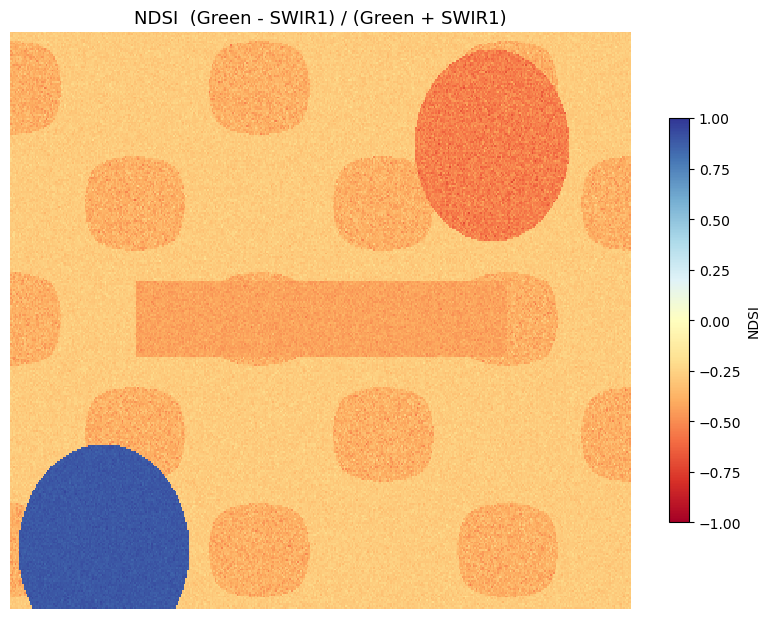

In [4]:
ndsi_result = ndsi(green, swir1)

fig, ax = plt.subplots(figsize=(10, 7.5))
ndsi_result.plot.imshow(ax=ax, cmap='RdYlBu', vmin=-1, vmax=1,
                        add_colorbar=True,
                        cbar_kwargs={'label': 'NDSI', 'shrink': 0.7})
ax.set_title('NDSI  (Green - SWIR1) / (Green + SWIR1)', fontsize=13)
ax.set_axis_off()

Snow shows up as a strong positive (blue). Everything else is near zero or negative. The burned patch and vegetation are both negative because their SWIR reflectance exceeds green.

## NDBI

The [Normalized Difference Built-up Index](https://doi.org/10.1080/01431160304987) (Zha et al. 2003) computes `(SWIR1 - NIR) / (SWIR1 + NIR)`. Impervious surfaces (concrete, asphalt, rooftops) reflect more SWIR than NIR, pushing NDBI positive. Vegetation goes strongly negative because NIR dominates.

The central urban strip should be the only positive feature below.

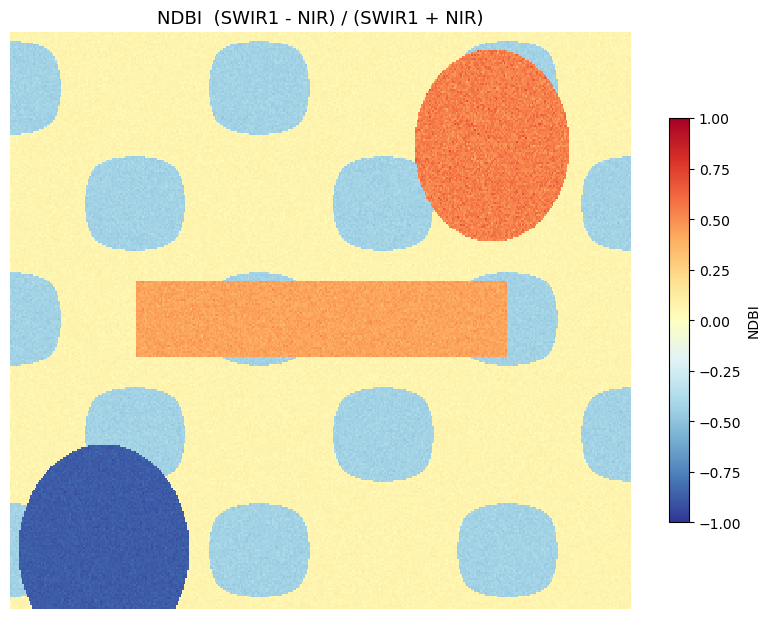

In [5]:
ndbi_result = ndbi(swir1, nir)

fig, ax = plt.subplots(figsize=(10, 7.5))
ndbi_result.plot.imshow(ax=ax, cmap='RdYlBu_r', vmin=-1, vmax=1,
                        add_colorbar=True,
                        cbar_kwargs={'label': 'NDBI', 'shrink': 0.7})
ax.set_title('NDBI  (SWIR1 - NIR) / (SWIR1 + NIR)', fontsize=13)
ax.set_axis_off()

The urban strip is the only region with positive NDBI. Vegetation patches are strongly negative. Snow is also very negative because its SWIR is near zero while NIR is high. Bare soil and burned areas hover near zero.

## BAI

The [Burn Area Index](https://doi.org/10.1080/01431160110053185) (Chuvieco et al. 2002) takes a different approach from normalized ratios. It measures the spectral distance of each pixel to a charcoal reflectance point at red=0.1 and NIR=0.06:

`BAI = 1 / ((0.1 - red)^2 + (0.06 - NIR)^2)`

Pixels close to the charcoal point get high BAI values. The burned patch in our scene was built with reflectance values near that point, so it should spike.

Input bands must be in reflectance units (0 to 1). If your data is in DN or scaled integers, scale it first.

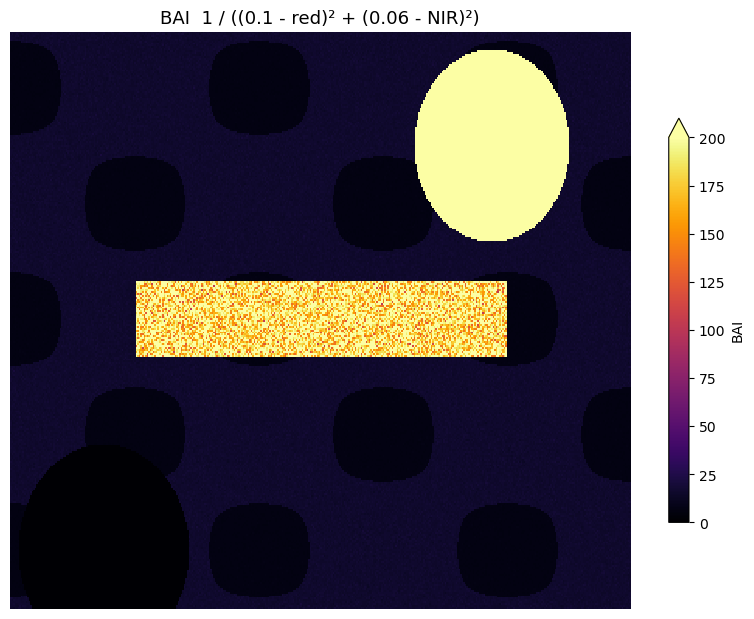

In [6]:
bai_result = bai(red, nir)

fig, ax = plt.subplots(figsize=(10, 7.5))
# Clip display range to bring out the burned patch; background values are low
bai_result.plot.imshow(ax=ax, cmap='inferno', vmin=0, vmax=200,
                       add_colorbar=True,
                       cbar_kwargs={'label': 'BAI', 'shrink': 0.7})
ax.set_title('BAI  1 / ((0.1 - red)² + (0.06 - NIR)²)', fontsize=13)
ax.set_axis_off()

The burned patch lights up with high BAI values. Everything else stays near the bottom of the scale because their red and NIR reflectance are far from the charcoal point.

<div class="alert alert-block alert-warning">
<b>BAI requires reflectance-scale data.</b> The charcoal reference point (0.1, 0.06) assumes bands are in 0-to-1 surface reflectance. Passing raw DN values (e.g. 0-10000) will produce tiny BAI values everywhere. Divide by the scale factor for your sensor first.
</div>

## MSAVI2

The [Modified Soil Adjusted Vegetation Index](https://doi.org/10.1016/0034-4257(94)90134-1) (Qi et al. 1994) is a self-adjusting vegetation index:

`MSAVI2 = (2 * NIR + 1 - sqrt((2 * NIR + 1)² - 8 * (NIR - red))) / 2`

SAVI requires the user to pick an L parameter for soil brightness correction. MSAVI2 computes its own correction internally, which makes it more practical when you don't have ground truth for soil type. It works best in sparse canopy where soil shows through the vegetation.

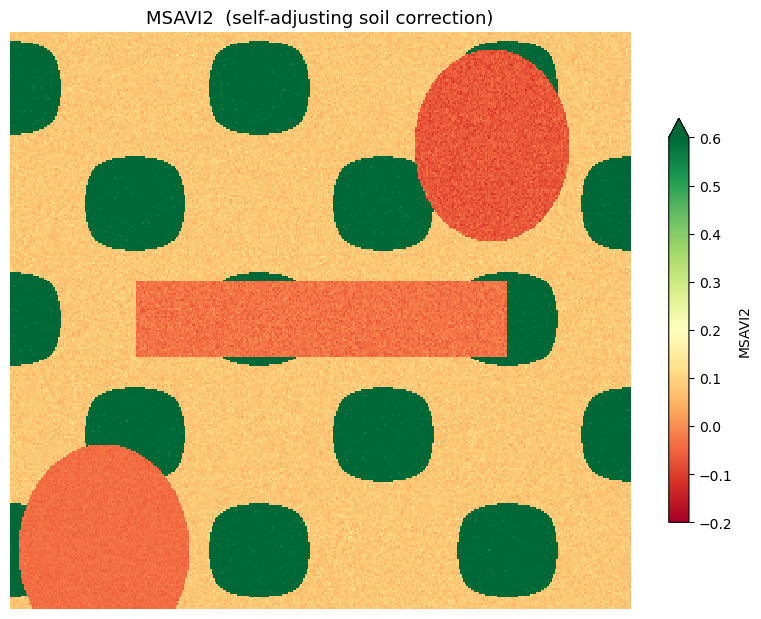

In [7]:
msavi2_result = msavi2(nir, red)

fig, ax = plt.subplots(figsize=(10, 7.5))
msavi2_result.plot.imshow(ax=ax, cmap='RdYlGn', vmin=-0.2, vmax=0.6,
                          add_colorbar=True,
                          cbar_kwargs={'label': 'MSAVI2', 'shrink': 0.7})
ax.set_title('MSAVI2  (self-adjusting soil correction)', fontsize=13)
ax.set_axis_off()

Vegetation patches are clearly the highest values (green). Bare soil sits in the middle. Snow, urban, and burned areas cluster at the low end. The soil correction keeps bare-ground values suppressed compared to what plain NDVI would show.

## OSAVI

The [Optimized Soil Adjusted Vegetation Index](https://doi.org/10.1016/0034-4257(95)00186-7) (Rondeaux et al. 1996) is a simplified SAVI with a fixed soil factor of L=0.16:

`OSAVI = (NIR - red) / (NIR + red + 0.16)`

Rondeaux et al. found that L=0.16 works well across a wide range of soil conditions without per-scene tuning. For dense canopy, OSAVI converges toward NDVI (the 0.16 becomes negligible). For sparse canopy with visible soil, it suppresses soil brightness better than NDVI.

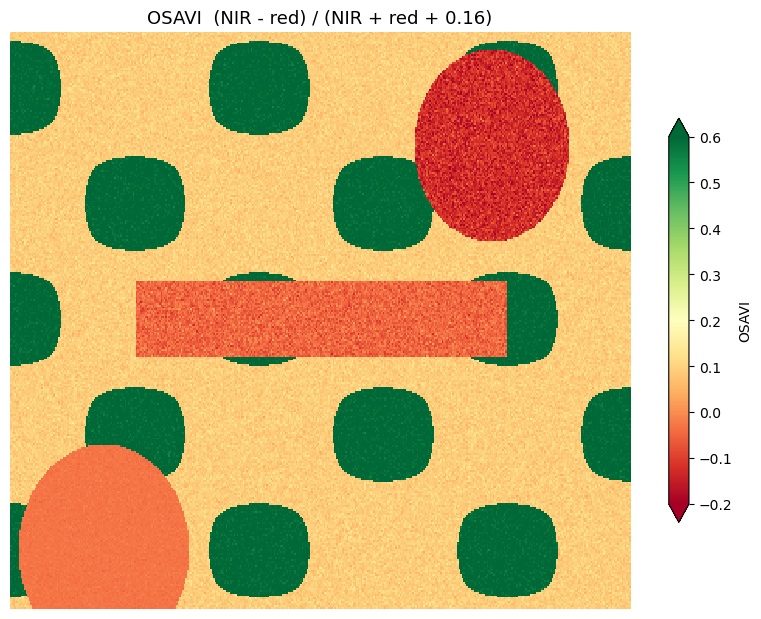

In [8]:
osavi_result = osavi(nir, red)

fig, ax = plt.subplots(figsize=(10, 7.5))
osavi_result.plot.imshow(ax=ax, cmap='RdYlGn', vmin=-0.2, vmax=0.6,
                         add_colorbar=True,
                         cbar_kwargs={'label': 'OSAVI', 'shrink': 0.7})
ax.set_title('OSAVI  (NIR - red) / (NIR + red + 0.16)', fontsize=13)
ax.set_axis_off()

The spatial pattern looks similar to MSAVI2, which makes sense since both are trying to pull out vegetation while correcting for soil. The absolute values differ because the formulas are different, but the relative ranking of land-cover types is the same: vegetation > bare soil > the rest.

## All five together

Placing all five indices side by side shows how each one isolates a different land-cover type from the same input bands. No single index does everything, but together they cover snow, urban, burn, and vegetation mapping.

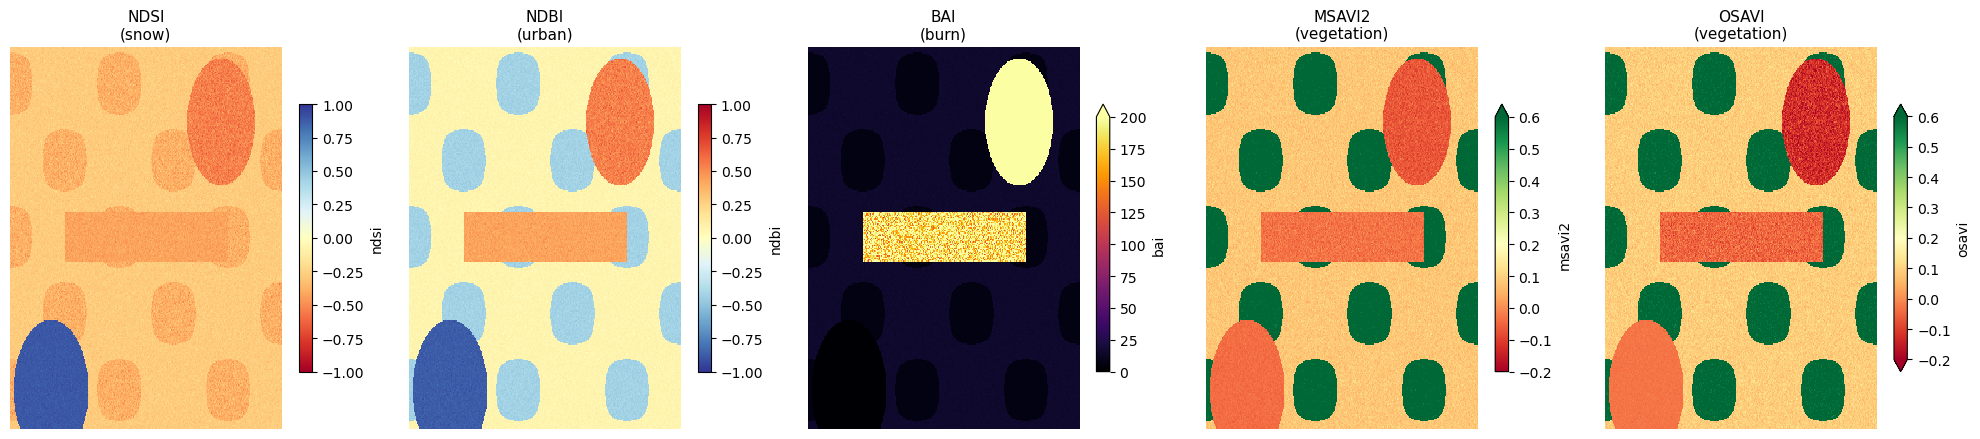

In [9]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

configs = [
    (ndsi_result, 'NDSI\n(snow)', 'RdYlBu', -1, 1),
    (ndbi_result, 'NDBI\n(urban)', 'RdYlBu_r', -1, 1),
    (bai_result, 'BAI\n(burn)', 'inferno', 0, 200),
    (msavi2_result, 'MSAVI2\n(vegetation)', 'RdYlGn', -0.2, 0.6),
    (osavi_result, 'OSAVI\n(vegetation)', 'RdYlGn', -0.2, 0.6),
]

for ax, (data, title, cmap, vmin, vmax) in zip(axes, configs):
    data.plot.imshow(ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                     add_colorbar=True, cbar_kwargs={'shrink': 0.7})
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

plt.tight_layout()

# Save preview image
fig.savefig('images/spectral_indices_preview.png',
            bbox_inches='tight', dpi=120)

<div class="alert alert-block alert-danger">
<b>Band assignments differ by sensor.</b> Green is Band 3 on both Landsat 8 and Sentinel-2, but NIR is Band 5 vs. Band 8, and SWIR1 is Band 6 vs. Band 11. Passing the wrong band silently produces garbage. Always check your sensor's band table.
</div>

### References

- Hall, D.K., Riggs, G.A. and Salomonson, V.V., 1995. [Development of methods for mapping global snow cover using MODIS data](https://nsidc.org/data/mod10a1). Remote Sensing of Environment, 54(2), pp.127-140.
- Zha, Y., Gao, J. and Ni, S., 2003. [Use of normalized difference built-up index in automatically mapping urban areas from TM imagery](https://doi.org/10.1080/01431160304987). International Journal of Remote Sensing, 24(3), pp.583-594.
- Chuvieco, E., Martin, M.P. and Palacios, A., 2002. [Assessment of different spectral conditions for the detection of burned areas](https://doi.org/10.1080/01431160110053185). International Journal of Remote Sensing, 23(1), pp.71-85.
- Qi, J., Chehbouni, A., Huete, A.R., Kerr, Y.H. and Sorooshian, S., 1994. [A modified soil adjusted vegetation index](https://doi.org/10.1016/0034-4257(94)90134-1). Remote Sensing of Environment, 48(2), pp.119-126.
- Rondeaux, G., Steven, M. and Baret, F., 1996. [Optimization of soil-adjusted vegetation indices](https://doi.org/10.1016/0034-4257(95)00186-7). Remote Sensing of Environment, 55(2), pp.95-107.
- [Landsat 8 band designations](https://www.usgs.gov/faqs/what-are-band-designations-landsat-satellites), USGS
- [xrspatial multispectral API docs](https://makepath.github.io/xarray-spatial/reference/_autosummary/xrspatial.multispectral.html)